# Hyperparameter Search

Presents the search that fixed the settings in `src/modeling/config.py`. Like `eda.ipynb`,
this notebook sits outside the numbered pipeline: the numbered notebooks can regenerate
their outputs from scratch, while this one presents archived runs that cannot be cheaply
reproduced.

The search was greedy coordinate descent in three stages, not a grid: learning rate first,
then model capacity at the winning rate, then regularization at the winning rate and
capacity. Each candidate changed exactly one setting away from the incumbent and trained
on fold 0 only (about 5 minutes) as a cheap screen; only the finalists got the full 5 fold
treatment before the winner was frozen.

Every number below is read from the run artifacts under `experiments/<run>/`
(`config.json` and `summary.json`), so it all traces to disk. One caveat: these are
archived runs. When the winner was frozen, the command line override machinery was
deliberately removed from `train.py`, so rerunning a search arm today means editing
`src/modeling/config.py` or `model.py` by hand. Since `experiments/` is gitignored, this
notebook's committed outputs are the durable record of the search.

In [1]:
import json
from pathlib import Path

import pandas as pd

REPO_ROOT = Path.cwd().parent
EXPERIMENTS = REPO_ROOT / "experiments"


def summary(run_name):
    """Load one run's summary.json as a dict."""
    return json.loads((EXPERIMENTS / run_name / "summary.json").read_text())


def fold0_score(run_name):
    """A run's fold 0 macro-F1, the screening metric."""
    return summary(run_name)["folds"]["0"]["macro_f1"]

## Screening: one change per run, scored on fold 0

The baseline is the starting configuration (lr 3e-4, lstm_hidden 128, CNN channels
32/64/128, dropout 0.3, weight decay 1e-4). Stage 1 varied only the learning rate; 1e-3
won and became the incumbent. Stages 2 and 3 varied capacity and regularization at
lr 1e-3, so their bars compete against the incumbent line, not the baseline line.

In [2]:
screens = [
    ("baseline",         "stage 0", "the defaults (lr 3e-4)"),
    ("screen_lr_1e-4",   "stage 1", "lr 1e-4"),
    ("screen_lr_1e-3",   "stage 1", "lr 1e-3"),
    ("screen_lr_3e-3",   "stage 1", "lr 3e-3"),
    ("screen_lstm64",    "stage 2", "lstm_hidden 64, at lr 1e-3"),
    ("screen_lstm256",   "stage 2", "lstm_hidden 256, at lr 1e-3"),
    ("screen_cnn_small", "stage 2", "cnn 16/32/64, at lr 1e-3"),
    ("screen_bilstm",    "stage 2", "bidirectional LSTM, at lr 1e-3"),
    ("screen_drop_0.1",  "stage 3", "dropout 0.1, at lr 1e-3"),
    ("screen_drop_0.5",  "stage 3", "dropout 0.5, at lr 1e-3"),
    ("screen_wd_1e-3",   "stage 3", "weight_decay 1e-3, at lr 1e-3"),
]
table = pd.DataFrame(
    [(run, stage, change, fold0_score(run)) for run, stage, change in screens],
    columns=["run", "stage", "change", "fold0_macro_f1"])
table.round(4)

,run,stage,change,fold0_macro_f1
0,baseline,stage 0,the defaults (lr 3e-4),0.8184
1,screen_lr_1e-4,stage 1,lr 1e-4,0.7877
2,screen_lr_1e-3,stage 1,lr 1e-3,0.8731
3,screen_lr_3e-3,stage 1,lr 3e-3,0.8195
4,screen_lstm64,stage 2,"lstm_hidden 64, at lr 1e-3",0.8153
5,screen_lstm256,stage 2,"lstm_hidden 256, at lr 1e-3",0.8135
6,screen_cnn_small,stage 2,"cnn 16/32/64, at lr 1e-3",0.8499
7,screen_bilstm,stage 2,"bidirectional LSTM, at lr 1e-3",0.8329
8,screen_drop_0.1,stage 3,"dropout 0.1, at lr 1e-3",0.8150
9,screen_drop_0.5,stage 3,"dropout 0.5, at lr 1e-3",0.7823


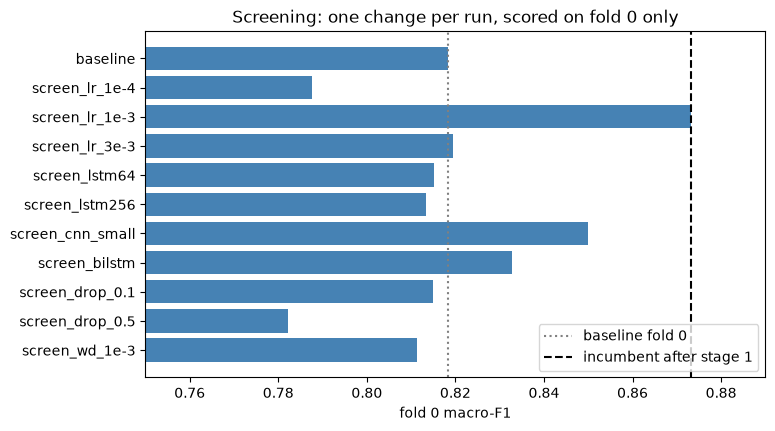

In [3]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(table["run"], table["fold0_macro_f1"], color="steelblue")
ax.axvline(fold0_score("baseline"), color="gray", linestyle=":",
           label="baseline fold 0")
ax.axvline(fold0_score("screen_lr_1e-3"), color="black", linestyle="--",
           label="incumbent after stage 1")
ax.set_xlim(0.75, 0.89)
ax.set_xlabel("fold 0 macro-F1")
ax.invert_yaxis()
ax.legend(loc="lower right")
ax.set_title("Screening: one change per run, scored on fold 0 only")
plt.show()

Learning rate was the only change that clearly helped: 1e-3 gained 5.5 points over the
baseline on fold 0, while 1e-4 undertrained and 3e-3 collapsed to an early peak. At
lr 1e-3, every capacity and regularization change lost ground against the incumbent. The
smaller CNN was the closest runner, down only 2.3 points while cutting the CNN
parameters roughly in half, so it advanced to full confirmation alongside the plain
learning rate change.

## Full cross validation confirmation

Fold 0 screening picks finalists, it does not pick the winner. Two configurations went
through the full 5 fold protocol next to the baseline: the stage 1 incumbent (lr 1e-3)
and its closest challenger (lr 1e-3 with the smaller CNN). The standard deviation uses
the same population formula as `summary.json`.

In [4]:
def fold_scores(run_name):
    """Per fold macro-F1 of a run, keyed by fold number."""
    return {int(k): v["macro_f1"] for k, v in summary(run_name)["folds"].items()}


cv = pd.DataFrame({
    "baseline (lr 3e-4)": fold_scores("baseline"),
    "lr 1e-3": fold_scores("cv_lr_1e-3"),
    "lr 1e-3 + cnn 16/32/64": fold_scores("cv_lr_1e-3_cnn_small"),
})
cv.index.name = "fold"
means, stds = cv.mean(), cv.std(ddof=0)
cv.loc["mean"] = means
cv.loc["std"] = stds
cv.round(4)

,baseline (lr 3e-4),lr 1e-3,lr 1e-3 + cnn 16/32/64
fold,,,
0,0.8184,0.8731,0.8499
1,0.7648,0.7615,0.8125
2,0.7782,0.7971,0.8149
3,0.7931,0.8105,0.7904
4,0.7941,0.8132,0.7925
mean,0.7897,0.8111,0.8120
std,0.0179,0.0361,0.0214


In [5]:
# the paired view: same folds, so differences cancel fold difficulty
diff = (cv.loc[range(5), "lr 1e-3 + cnn 16/32/64"]
        - cv.loc[range(5), "baseline (lr 3e-4)"]) * 100
print("winner minus baseline, percentage points per fold:")
print(diff.round(1).to_string())
print(f"mean improvement: {diff.mean():.1f} points")

winner minus baseline, percentage points per fold:
fold
0    3.2
1    4.8
2    3.7
3   -0.3
4   -0.2
mean improvement: 2.2 points


The full CV rewrote the screening story. The finalists tie on the mean (0.8111 vs
0.8120) and both beat the baseline by about 2 points, far less than fold 0 suggested.
The paired differences show the winner's edge comes from three of the five folds with
the other two essentially unchanged, so the improvement is directional rather than
decisive. The smaller CNN won the tie on lower fold variance (std 0.021 vs 0.036) and
roughly half the CNN parameters.

## How much did fold 0 screening flatter the candidates?

Screening on one fixed fold selects for configurations that fold happens to like. The
two finalists were measured both ways, so the bias is observable directly.

In [6]:
bias = pd.DataFrame({
    "fold 0 screen": [fold0_score("screen_lr_1e-3"),
                      fold0_score("screen_cnn_small")],
    "full cv mean": [summary("cv_lr_1e-3")["mean_macro_f1"],
                     summary("cv_lr_1e-3_cnn_small")["mean_macro_f1"]],
}, index=["lr 1e-3", "lr 1e-3 + cnn 16/32/64"])
bias["gap"] = bias["fold 0 screen"] - bias["full cv mean"]
bias.round(4)

,fold 0 screen,full cv mean,gap
lr 1e-3,0.8731,0.8111,0.0621
lr 1e-3 + cnn 16/32/64,0.8499,0.8120,0.0378


Fold 0 flattered both finalists: by 6.2 points for plain lr 1e-3 and 3.8 points for the
eventual winner. That is why screening scores were never quoted as results and every
conclusion waited for the full cross validation.

## Takeaways

- The search's real finding is that the starting configuration was already near a local
  optimum: of ten single setting changes, only the learning rate clearly helped, and the
  final model differs from the defaults by just two settings (lr 1e-3, CNN 16/32/64).
- The winner improves on the baseline by 2.2 points of macro-F1 on average (0.812 vs
  0.790), driven by three of five folds. It was chosen over the statistically tied plain
  lr 1e-3 finalist for its lower fold variance and smaller CNN.
- Two honesty caveats for the report. Greedy search assumes away interactions between
  settings: the best learning rate for a larger LSTM, for example, was never measured; a
  grid would catch such interactions at 3 to 5 times the cost. And screening on a fixed
  fold ran 4 to 6 points hot versus full CV, a bias measured directly above, which is why
  finalists were always confirmed on all folds before any conclusion was drawn.